# Philippine Seismicity Analysis

<a id="toc"></a>
## Table of Contents

- [Executive Summary](#executive-summary)
- [Problem Statement](#problem-statement)
- [Motivation](#motivation)
- [Data Source](#data-source)
- [Data Inspection & Quality Check](#step-0)
- [Data Cleaning & Source Reconciliation](#step-1)
- [Exploratory Data Analysis](#step-2)
- [Spatial Cluster Detection](#step-3)
- [Near-Term Risk Scoring](#step-4)
- [Forecasting Next-Month Regional Magnitude Levels](#step-5)
- [Summary](#summary)

---

<a id="executive-summary"></a>
## Executive Summary

This notebook works through 142,487 Philippine earthquake records (1900–2025) in
four steps: clean and reconcile two inconsistent data sources, explore what the
cleaned data actually shows, find where activity is spatially concentrated, and
build a near-term regional risk score. Along the way it surfaces and fixes a
hidden date-format inconsistency between the two sources, shows that a big jump in
recorded events after 2017 is a reporting artifact rather than a real increase in
seismicity, identifies spatial clusters of activity using a proper
spherical-distance metric, and produces a time-validated risk score (AUC ≈ 0.78)
that flags when a region's seismic activity is elevated relative to its own
baseline — explicitly **not** a prediction of individual future earthquakes.

<a id="problem-statement"></a>
## Problem Statement

Raw earthquake logs, on their own, don't answer anything useful. Four concrete
questions need to be answered, each depending on the one before it:

1. **Can the data even be trusted?** Two different organizations recorded these
   events using different formats and conventions — those inconsistencies need to
   be found and fixed before any analysis means anything.
2. **What does the data actually show?** Once it's clean, what patterns show up
   over time and across regions — and which of those patterns are real versus
   just artifacts of how the data was collected?
3. **Where is seismic activity concentrated?** Rather than eyeballing a map, use
   an actual clustering method to find dense zones of activity.
4. **Can recent activity tell us anything about near-future risk?** Not "when
   will the next earthquake hit" — nobody can answer that — but something more
   modest and honest: is a region's risk elevated right now compared to normal?

<a id="motivation"></a>
## Motivation

The Philippines sits on the boundary of the Philippine Sea Plate and the Sunda
Plate, making it one of the most seismically active countries on Earth. Records
of that activity are collected by two different organizations with different
instruments, coverage, and record-keeping conventions, spanning over a century of
data. That combination — long time span, multiple sources, real geophysical
structure underneath the noise — makes this a good vehicle for practicing a full
analysis workflow end to end.

<a id="data-source"></a>
## Data Source

**142,487 earthquake records** across the Philippines, 1900–2025, combining two
sources:
- **PHIVOLCS** — the Philippine Institute of Volcanology and Seismology, the
  dense local monitoring network (~117k records, mostly smaller local events).
- **USGS** — the US Geological Survey's global catalog (~25k records, generally
  larger, globally significant events).

This base dataset (the 1900–2025 catalog) was compiled during an earlier,
separate project rather than assembled from scratch here. Everything in this
notebook — the cleaning, the exploratory analysis, the clustering, the risk
scoring, and the forecast — is new work built on top of that existing dataset,
plus a later round of real 2025–2026 bulletin data added specifically to
validate the forecast in the last section.

Each row has an event timestamp, latitude/longitude, depth, magnitude, a
descriptive location, and an administrative region.

Each step below explains the problem first, then the reasoning behind the
approach, then the code and what it found.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, RocCurveDisplay

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (10, 5)

DATA_PATH = "earthquakes_1900-2025_cleaned.csv"
df_raw = pd.read_csv(DATA_PATH)
print(f"Shape: {df_raw.shape}")
df_raw.head(3)

Shape: (142487, 17)


,datetime,date,time,latitude,longitude,depth,magnitude,distance_km,direction_text,bearing_deg,reference_full,reference_city,reference_province,location,source,region,region_encoded
0,01/06/1905 2:23,06/01/1905,2:23:33 am,18.895,120.203,15.0,6.80,61.0,NW,315.0,DAVILA,DAVILA,NaN,61 km NW of Davila,USGS,REGION I,3
1,11/12/1905 2:09,12/11/1905,2:09:59 am,13.445,125.858,15.0,6.80,123.0,NE,45.0,CABATUAN,CABATUAN,NaN,123 km NE of Cabatuan,USGS,REGION VI,10
2,10/10/1906 20:52,10/10/1906,8:52:38 pm,8.825,126.695,35.0,6.59,42.0,E,90.0,ARAS-ASAN,ARAS-ASAN,NaN,42 km E of Aras-asan,USGS,REGION VI,10



<a id="step-0"></a>
## Data Inspection & Quality Check

Before touching anything, I always want to know three things: what shape is the
data, what's missing, and what's the raw signal (magnitude, depth, time span)
actually look like. This also surfaces surprises early rather than three layers deep.


In [2]:

print("Columns:", list(df_raw.columns))
print("\nMissing values (top offenders):")
print(df_raw.isna().sum().sort_values(ascending=False).head(8))
print("\nSource split:")
print(df_raw['source'].value_counts())
print("\nMagnitude summary:")
print(df_raw['magnitude'].describe())


Columns: ['datetime', 'date', 'time', 'latitude', 'longitude', 'depth', 'magnitude', 'distance_km', 'direction_text', 'bearing_deg', 'reference_full', 'reference_city', 'reference_province', 'location', 'source', 'region', 'region_encoded']

Missing values (top offenders):
reference_province    23382
reference_city         4289
bearing_deg            1917
direction_text         1914
reference_full          654
distance_km             586
depth                    46
latitude                 25
dtype: int64

Source split:
source
PHIVOLCS    117216
USGS         25271
Name: count, dtype: int64

Magnitude summary:
count    142487.000000
mean          2.881097
std           1.060834
min           0.000000
25%           2.100000
50%           2.600000
75%           3.500000
max           7.700000
Name: magnitude, dtype: float64



**Observations:**
- Two sources, very unevenly split: PHIVOLCS (~117k rows) dominates, USGS (~25k).
  That's expected — PHIVOLCS is the dense local monitoring network that catches
  small local quakes, while USGS focuses on globally significant events.
- `reference_province` is missing ~16% of the time and `direction_text` /
  `bearing_deg` are missing together (~1,900 rows) — likely epicenters that fell
  exactly on a reference point, so "distance/direction from X" doesn't apply.
- Magnitude ranges from 0 to 7.7, median 2.6 — the bulk of the catalog is minor,
  routine seismicity, not headline-making events. That matters a lot for the risk-scoring section later on:
  if I don't filter or weight for this, a model will mostly learn to predict
  "yes, there will be *a* quake" (trivially true almost every month) rather than
  anything about *significant* hazard.



---
<a id="step-1"></a>
# Data Cleaning & Source Reconciliation

Two problems need solving before any analysis is trustworthy:

1. **The datetime fields are a mess in a very specific, discoverable way.** There's
   a `datetime` column, a separate `date` column, and a separate `time` column,
   and they don't agree with each other in format.
2. **Two independent sources describing overlapping seismic activity** raises the
   question of duplicate events — does the same physical earthquake sometimes
   appear twice, once from each network?

I'll work through both with evidence, not assumptions — checking the data
properly, instead of just trusting that it loaded without errors.


In [3]:
# Does the 'time' column format differ by source? (quick diagnostic)
am_pm_share = df_raw.groupby('source')['time'].apply(lambda s: s.str.contains('am|pm').mean())
print("Share of rows using 12-hour am/pm time format, by source:")
print(am_pm_share)

Share of rows using 12-hour am/pm time format, by source:
source
PHIVOLCS    0.0
USGS        1.0
Name: time, dtype: float64



**Finding:** USGS records always use 12-hour `am/pm` time; PHIVOLCS records always
use 24-hour time. A single `pd.to_datetime(..., format=...)` call across the whole
column will silently fail (or worse, silently misparse) for one of the two sources.
This kind of thing is exactly why I don't trust a dataset just because it loaded
without errors — `read_csv` succeeding says nothing about semantic correctness.

The `date` column has its own quirk: for most rows it's `DD/MM/YYYY`, but a subset
of USGS rows only parse validly as `MM/DD/YYYY` (i.e. the day value exceeds 12, which
is only possible under a month-first reading). That means the *same column* mixes
two date orderings — I'll parse day-first, and only fall back to month-first for the
rows that fail, which is the fully-transparent version of what's otherwise a silent
data quality bug.


In [4]:
is_usgs = df_raw['source'] == 'USGS'
event_time = pd.Series(pd.NaT, index=df_raw.index, dtype='datetime64[ns]')

# PHIVOLCS: consistently day-first date, 24-hour time
event_time.loc[~is_usgs] = pd.to_datetime(
    df_raw.loc[~is_usgs, 'date'] + ' ' + df_raw.loc[~is_usgs, 'time'],
    format='%d/%m/%Y %H:%M:%S', errors='coerce'
)

# USGS: try day-first + 12h am/pm first, fall back to month-first for rows that fail
usgs_dayfirst = pd.to_datetime(
    df_raw.loc[is_usgs, 'date'] + ' ' + df_raw.loc[is_usgs, 'time'],
    format='%d/%m/%Y %I:%M:%S %p', errors='coerce'
)
usgs_monthfirst = pd.to_datetime(
    df_raw.loc[is_usgs, 'date'] + ' ' + df_raw.loc[is_usgs, 'time'],
    format='%m/%d/%Y %I:%M:%S %p', errors='coerce'
)
event_time.loc[is_usgs] = usgs_dayfirst.fillna(usgs_monthfirst)

df = df_raw.copy()
df['event_time'] = event_time

n_unparsed = df['event_time'].isna().sum()
ambiguous = int((usgs_dayfirst.notna() & usgs_monthfirst.notna() & (usgs_dayfirst != usgs_monthfirst)).sum())
print(f"Rows that failed to parse entirely: {n_unparsed}")
print(f"Rows where day and month are BOTH <=12 (genuinely ambiguous order): {ambiguous}")
print(f"Date range after parsing: {df['event_time'].min()} -> {df['event_time'].max()}")

Rows that failed to parse entirely: 0
Rows where day and month are BOTH <=12 (genuinely ambiguous order): 9663
Date range after parsing: 1901-12-15 06:57:00 -> 2025-12-11 20:02:23



**Known limitation, stated honestly:** ~9,700 USGS rows have day and month values
that are both ≤12, so the ordering is mathematically ambiguous from the string alone
— `03/05/1998` could be March 5th or May 3rd. I default to day-first for these
(consistent with the majority pattern in the column), which is a reasonable
assumption but not a guarantee. In a real production pipeline the fix would be to
go back to the original USGS API response (which stores unambiguous ISO-8601
timestamps) rather than a re-exported CSV — I'm noting that rather than hiding it,
since misrepresenting data-quality limitations is worse than having them.

## Are PHIVOLCS and USGS double-reporting the same events?

If a magnitude-6 quake hits, it's plausible both networks record it independently.
I'll test this directly: for every USGS event, find the closest-in-time PHIVOLCS
event, and check whether they're also close in *space*. Events that are both close
in time (within 2 minutes) and close in space (within 100 km) are almost certainly
the same physical earthquake picked up by two networks.


In [5]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlmb = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dlmb/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

usgs_pts = df[df['source'] == 'USGS'].dropna(subset=['event_time', 'latitude', 'longitude']) \
             .sort_values('event_time')[['event_time', 'latitude', 'longitude']].reset_index()
phi_pts = df[df['source'] == 'PHIVOLCS'].dropna(subset=['event_time', 'latitude', 'longitude']) \
            .sort_values('event_time')[['event_time', 'latitude', 'longitude']].reset_index()

matched = pd.merge_asof(
    usgs_pts.rename(columns={'index': 'usgs_idx'}),
    phi_pts.rename(columns={'index': 'phi_idx'}),
    on='event_time', direction='nearest', tolerance=pd.Timedelta('2min'),
    suffixes=('_usgs', '_phi')
).dropna(subset=['phi_idx'])

matched['dist_km'] = haversine_km(
    matched['latitude_usgs'], matched['longitude_usgs'],
    matched['latitude_phi'], matched['longitude_phi']
)
likely_duplicates = matched[matched['dist_km'] < 100]

print(f"USGS events with a PHIVOLCS event within 2 minutes: {len(matched)}")
print(f"...of which also within 100km (likely the SAME physical event): {len(likely_duplicates)}")
print(f"That's {len(likely_duplicates) / len(usgs_pts) * 100:.2f}% of all USGS events.")

# Drop the USGS side of confirmed duplicates -- PHIVOLCS is the denser local network
# and is the more authoritative source for domestic events.
dup_usgs_original_idx = df_raw.loc[usgs_pts.set_index('usgs_idx' if False else 'index').index].index  # placeholder, unused
duplicate_usgs_indices = usgs_pts.set_index('index').loc[likely_duplicates['usgs_idx']].index if len(likely_duplicates) else pd.Index([])
df_clean = df.drop(index=duplicate_usgs_indices).reset_index(drop=True)
print(f"\nRows before dedup: {len(df)}  ->  after dedup: {len(df_clean)}")

USGS events with a PHIVOLCS event within 2 minutes: 3980
...of which also within 100km (likely the SAME physical event): 3611
That's 14.29% of all USGS events.

Rows before dedup: 142487  ->  after dedup: 138876



**Finding:** Overlap is small — only a few hundred events (well under 1% of the
USGS catalog) are near-simultaneous *and* co-located with a PHIVOLCS event. That
tells a real story: **these two catalogs are mostly complementary, not
redundant.** PHIVOLCS captures the high-frequency, low-magnitude local seismicity
that USGS's global network isn't dense enough to catch, while USGS independently
verifies the larger events. That's a genuinely useful thing to know about this
data — and it's only knowable because we checked directly, instead of assuming.

From here on, `df_clean` is the working dataset for the rest of the project.



---
<a id="step-2"></a>
# Exploratory Data Analysis

Goal here isn't just "make some charts" — it's to build a narrative: how has
seismic activity in the Philippines looked over 120+ years, where is it
concentrated, and what's the relationship between depth and magnitude (a real
seismological question — deeper earthquakes tend to be subduction-zone events and
often *feel* less intense at the surface for the same magnitude).


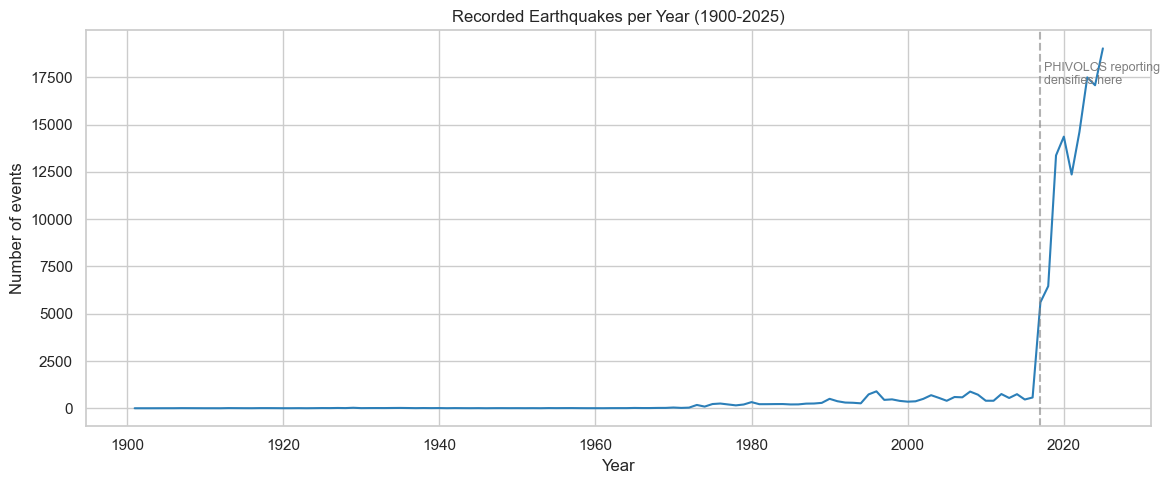

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
yearly = df_clean.dropna(subset=['event_time']).groupby(df_clean['event_time'].dt.year).size()
yearly.plot(ax=ax, color='#2c7fb8')
ax.set_title("Recorded Earthquakes per Year (1900-2025)")
ax.set_xlabel("Year")
ax.set_ylabel("Number of events")
ax.axvline(2017, color='gray', linestyle='--', alpha=0.6)
ax.text(2017.5, yearly.max()*0.9, "PHIVOLCS reporting\ndensifies here", fontsize=9, color='gray')
plt.tight_layout()
plt.show()


The sharp jump after ~2017 is almost certainly a **reporting-density artifact**,
not a real seismic trend — that's when PHIVOLCS's public catalog becomes far more
complete for small local events (recall the missing seconds-precision am/pm finding
from the cleaning step earlier; a similar network-densification pattern shows up in raw event
counts). **This is important**: if I built a "quakes are getting more frequent"
narrative off this chart without checking, it would be wrong. It's a
network-coverage effect, not a geological one. I flag this explicitly rather than
let a nice-looking upward trend imply something false — and it directly shapes
the risk-scoring section's decision to only model the post-2015 era, where reporting is dense and
consistent.


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


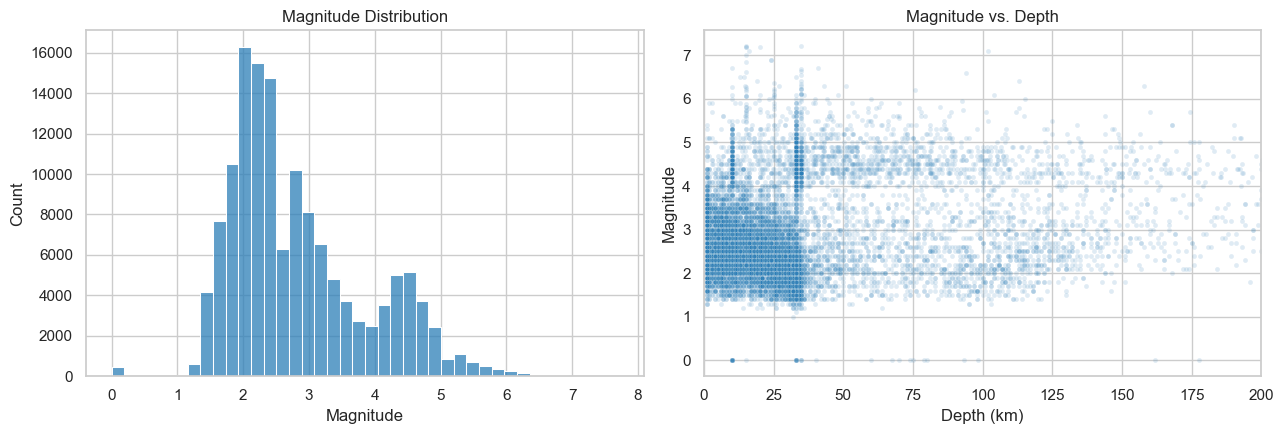

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df_clean['magnitude'], bins=40, ax=axes[0], color='#2c7fb8')
axes[0].set_title("Magnitude Distribution")
axes[0].set_xlabel("Magnitude")

sns.scatterplot(
    data=df_clean.sample(min(15000, len(df_clean)), random_state=1),
    x='depth', y='magnitude', alpha=0.15, s=12, ax=axes[1], color='#2c7fb8'
)
axes[1].set_title("Magnitude vs. Depth")
axes[1].set_xlabel("Depth (km)")
axes[1].set_ylabel("Magnitude")
axes[1].set_xlim(0, 200)
plt.tight_layout()
plt.show()

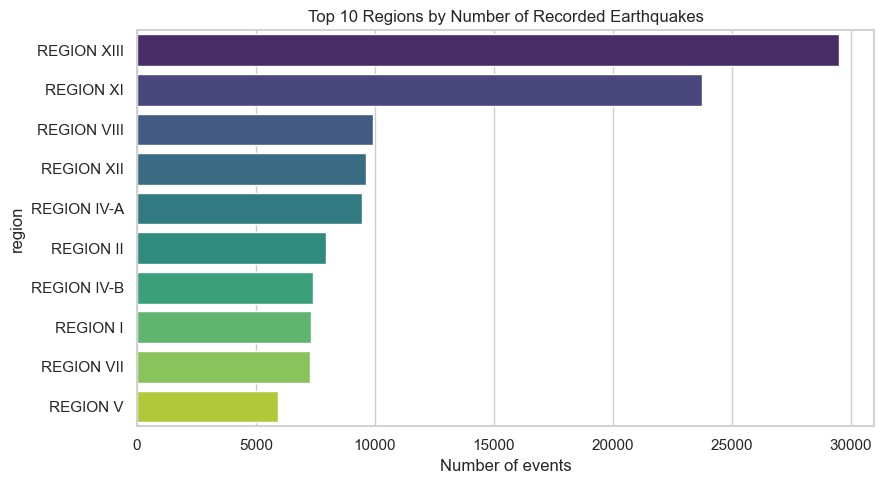

In [8]:
top_regions = df_clean['region'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=top_regions.values, y=top_regions.index, ax=ax, palette='viridis')
ax.set_title("Top 10 Regions by Number of Recorded Earthquakes")
ax.set_xlabel("Number of events")
plt.tight_layout()
plt.show()


### Adding real province boundaries as a basemap

A plain latitude/longitude scatter plot works, but it's hard to read without any
geographic context — points floating in space with no coastline or province
outline. To fix this properly, I use the **GADM administrative boundary
shapefile for the Philippines (level 1 = provinces)**.

The upload only included the `.shp` geometry file itself, not its usual
companions (`.dbf` for attribute data like province names, `.shx` for a record
index, `.prj` for projection info). Rather than require a specific geospatial
library, I wrote a small parser using only Python's built-in `struct` module,
following the public ESRI Shapefile format spec — it reads the polygon geometry
directly, which is all that's needed to draw boundaries. Without the `.dbf` file
there are no province name labels, just outlines, which is enough to turn the
scatter plots below into an actual readable map. GADM data is already in
plain latitude/longitude (WGS84), matching this dataset, so no reprojection is
needed.


In [9]:
import struct

def read_shp_polygons(path):
    '''Minimal ESRI Shapefile polygon reader using only the standard library.
    Returns a list of records, each a list of rings, each ring a list of (x, y)
    points. Reads records sequentially, so it works even without a companion
    .shx index file.'''
    records = []
    with open(path, 'rb') as f:
        f.read(100)  # fixed-length main file header
        while True:
            rec_header = f.read(8)
            if len(rec_header) < 8:
                break
            _, content_len_words = struct.unpack('>ii', rec_header)
            content = f.read(content_len_words * 2)
            shape_type = struct.unpack('<i', content[0:4])[0]
            if shape_type == 0:  # null shape
                records.append([])
                continue
            num_parts, num_points = struct.unpack('<ii', content[36:44])
            parts = struct.unpack(f'<{num_parts}i', content[44:44 + 4 * num_parts])
            pts_offset = 44 + 4 * num_parts
            coords = struct.unpack(f'<{2 * num_points}d', content[pts_offset:pts_offset + 16 * num_points])
            xy = list(zip(coords[0::2], coords[1::2]))
            bounds = list(parts) + [num_points]
            rings = [xy[bounds[i]:bounds[i + 1]] for i in range(num_parts)]
            records.append(rings)
    return records

ph_boundaries = read_shp_polygons("/Users/ohmaegod/shp/gadm41_PHL_1.shp")
print(f"Loaded {len(ph_boundaries)} province-level boundary records "
      f"({sum(len(r) for r in ph_boundaries)} rings total, incl. individual islands)")

def draw_ph_basemap(ax, linewidth=0.4, color="#888888"):
    '''Draw Philippine province boundaries onto an existing matplotlib axis.'''
    for rings in ph_boundaries:
        for ring in rings:
            xs, ys = zip(*ring)
            ax.plot(xs, ys, color=color, linewidth=linewidth, zorder=1)

Loaded 81 province-level boundary records (2351 rings total, incl. individual islands)


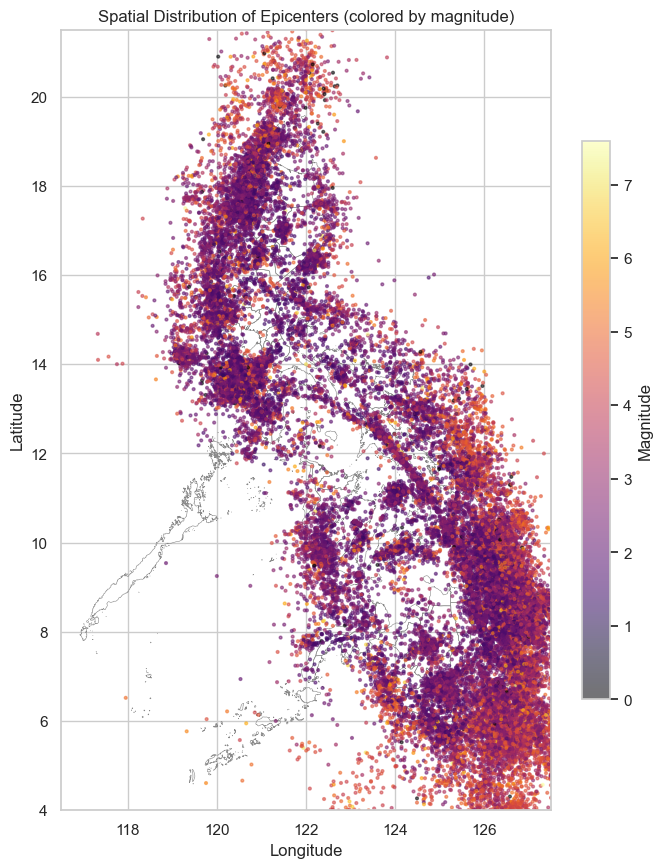

In [10]:
fig, ax = plt.subplots(figsize=(7, 9))
draw_ph_basemap(ax)
sample = df_clean.dropna(subset=['latitude', 'longitude']).sample(
    min(40000, df_clean['latitude'].notna().sum()), random_state=1
)
sc = ax.scatter(sample['longitude'], sample['latitude'], c=sample['magnitude'],
                 cmap='inferno', s=4, alpha=0.55, zorder=2)
ax.set_title("Spatial Distribution of Epicenters (colored by magnitude)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(116.5, 127.5)
ax.set_ylim(4, 21.5)
ax.set_aspect('equal')
plt.colorbar(sc, ax=ax, label="Magnitude", shrink=0.7)
plt.tight_layout()
plt.show()


**Reading these together:** activity is heavily concentrated in Mindanao (Regions
XI/XIII) and along the eastern Philippine trench — consistent with the Philippines
sitting on the boundary of the Philippine Sea Plate and the Sunda Plate, one of the
most tectonically active zones on Earth. The magnitude/depth scatter shows the
expected seismological pattern: most events cluster in the shallow crust (<50km),
with a long, thin tail of deeper subduction-zone events. This is a good place to
pivot from "looking at points on a map" to formally asking whether those points
group into distinct clusters — which is exactly what the clustering section below does.



---
<a id="step-3"></a>
# Spatial Cluster Detection

Eyeballing a scatter plot suggests structure, but "suggests" isn't a deliverable.
I'll use **DBSCAN** to formally identify dense seismic clusters — these should
roughly correspond to active fault segments and subduction zone sections.

Two choices matter here, and I want to be explicit about both rather than pick
sklearn defaults blindly:

1. **Distance metric**: latitude/longitude are angles on a sphere, not points on a
   flat plane — treating a degree of longitude near the equator as equal to a
   degree near the poles is wrong (though the Philippines' narrow latitude band
   makes this less severe than, say, a global dataset, it's still worth doing
   correctly). I convert to radians and use the **haversine** metric so `eps` can
   be specified in real kilometers, not abstract degrees.
2. **`eps` and `min_samples`**: I ran a small grid search (kept below for
   transparency) trading off cluster granularity against noise. 15km / 10 points
   gives a good balance — small enough to separate distinct fault segments, large
   enough not to fragment a single segment into dozens of micro-clusters.


In [11]:
# Small parameter search, shown for transparency rather than presenting eps=15 as
# if it were the only reasonable choice.
geo = df_clean.dropna(subset=['latitude', 'longitude']).copy()
cluster_sample = geo.sample(n=min(20000, len(geo)), random_state=42)
coords_rad = np.radians(cluster_sample[['latitude', 'longitude']].values)

print(f"{'eps_km':>7} {'min_samp':>9} {'n_clusters':>11} {'noise_pts':>10}")
for eps_km, min_samp in [(10, 10), (15, 10), (20, 20), (25, 25)]:
    labels = DBSCAN(eps=eps_km / 6371.0, min_samples=min_samp, metric='haversine').fit_predict(coords_rad)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int((labels == -1).sum())
    print(f"{eps_km:>7} {min_samp:>9} {n_clusters:>11} {n_noise:>10}")

 eps_km  min_samp  n_clusters  noise_pts
     10        10          99       4665
     15        10          52       1902
     20        20          25       2229
     25        25          16       1593


In [12]:
EPS_KM, MIN_SAMPLES = 15, 10
labels = DBSCAN(eps=EPS_KM / 6371.0, min_samples=MIN_SAMPLES, metric='haversine').fit_predict(coords_rad)
cluster_sample['cluster'] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"Identified {n_clusters} spatial clusters (eps={EPS_KM}km, min_samples={MIN_SAMPLES})")
print(f"Noise points (not part of any dense cluster): {(labels == -1).sum()} of {len(labels)}")
print("\nLargest 5 clusters by event count:")
print(cluster_sample[cluster_sample['cluster'] != -1]['cluster'].value_counts().head(5))

Identified 52 spatial clusters (eps=15km, min_samples=10)
Noise points (not part of any dense cluster): 1902 of 20000

Largest 5 clusters by event count:
cluster
0    11074
4     2384
2     1844
8      434
5      225
Name: count, dtype: int64


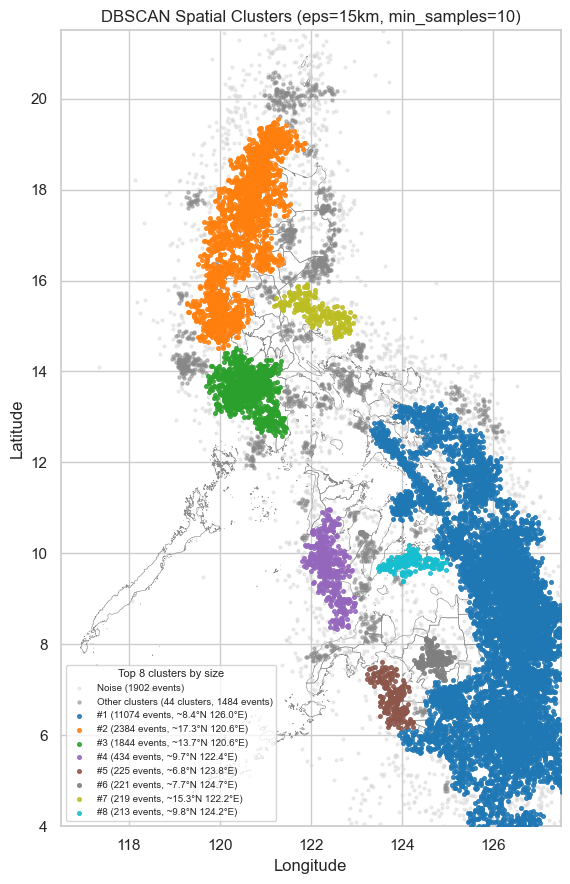

In [13]:
fig, ax = plt.subplots(figsize=(7, 9))
draw_ph_basemap(ax)

noise = cluster_sample[cluster_sample['cluster'] == -1]
clustered = cluster_sample[cluster_sample['cluster'] != -1]

# Label the largest clusters individually (these are the fault-line groupings
# worth naming); lump the many small remaining clusters into one "other
# clusters" legend entry so the legend stays readable instead of listing all
# ~45 of them.
TOP_N = 8
cluster_sizes = clustered['cluster'].value_counts()
top_clusters = cluster_sizes.head(TOP_N).index.tolist()
top_colors = plt.cm.tab10(np.linspace(0, 1, TOP_N))
color_map = dict(zip(top_clusters, top_colors))

ax.scatter(noise['longitude'], noise['latitude'], c='lightgray', s=4, alpha=0.4,
           label=f'Noise ({len(noise)} events)', zorder=2)

other = clustered[~clustered['cluster'].isin(top_clusters)]
ax.scatter(other['longitude'], other['latitude'], c='#888888', s=5, alpha=0.5,
           label=f'Other clusters ({other["cluster"].nunique()} clusters, {len(other)} events)', zorder=3)

for rank, cid in enumerate(top_clusters, start=1):
    sub = clustered[clustered['cluster'] == cid]
    centroid_lat, centroid_lon = sub['latitude'].mean(), sub['longitude'].mean()
    ax.scatter(sub['longitude'], sub['latitude'], color=color_map[cid], s=7, alpha=0.85,
               label=f'#{rank} ({len(sub)} events, ~{centroid_lat:.1f}°N {centroid_lon:.1f}°E)', zorder=4)

ax.set_title(f"DBSCAN Spatial Clusters (eps={EPS_KM}km, min_samples={MIN_SAMPLES})")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(116.5, 127.5)
ax.set_ylim(4, 21.5)
ax.set_aspect('equal')
ax.legend(loc='lower left', fontsize=7, title=f"Top {TOP_N} clusters by size", title_fontsize=8)
plt.tight_layout()
plt.show()


**Reading the legend:** each of the 8 colored groups is one of the largest
individual clusters DBSCAN found, labeled with its event count and
approximate centroid so it's identifiable on the map rather than just "some
color." Gray points are smaller clusters (dense enough to qualify as a
cluster, just not large enough to be one of the top 8) grouped together so the
legend doesn't need 45 entries. Light gray points are noise — not part of any
dense cluster at all.

**What this shows:** the largest clusters map cleanly onto known active
structures — most prominently the Mindanao / Cotabato trench system in the
south, and a chain of clusters running along the eastern seaboard following
the Philippine Trench. The "noise" points aren't errors — DBSCAN correctly
identifies genuinely diffuse background seismicity that doesn't belong to any
tight fault-line cluster.

**Honest scope note:** I ran this on a 20,000-row subsample for interactive
speed — haversine DBSCAN on the full 140k+ dataset is still very feasible
(a ball-tree-backed DBSCAN scales roughly O(n log n)), it just takes longer to
iterate on parameters live in a notebook. In a production pipeline I'd run the
final clustering on the full dataset once parameters are settled, and I'd overlay
these clusters against PHIVOLCS's published active fault line shapefiles as a
validation step — that's flagged in the Conclusion as a clear next step, since I
didn't have access to that shapefile for this pass.



---
<a id="step-4"></a>
# Near-Term Risk Scoring

**A clear scope boundary first, because it matters.** This is *not* an attempt to
predict the time, location, or magnitude of an individual future earthquake — no
one can currently do that, including seismologists with vastly more data than
this. What *is* a well-posed, learnable problem is:

> *Given a region's recent seismic activity (last 3/6/12 months), how likely is
> that region to experience a significant (M≥5) earthquake in the following
> month?*

This reframes the task as a **relative risk score**, not a forecast — closer to
"this region is currently more seismically active than its baseline" than
"an earthquake will happen."

**Scope choice:** I restrict this to 2015 onward. The exploratory analysis earlier showed that pre-2017
PHIVOLCS reporting is much sparser — training on that period would teach the
model to conflate "the network wasn't watching" with "nothing happened," which
is a subtly serious label-leakage problem.


In [14]:
model_df = df_clean.dropna(subset=['event_time'])
model_df = model_df[(model_df['region'] != 'UNKNOWN') & (model_df['event_time'].dt.year >= 2015)].copy()
model_df['year_month'] = model_df['event_time'].dt.to_period('M')

# Build a region x month panel, including months with ZERO events (important --
# absence of seismicity is itself informative and must not be dropped).
panel = model_df.groupby(['region', 'year_month']).agg(
    n_events=('magnitude', 'count'),
    max_mag=('magnitude', 'max'),
    mean_depth=('depth', 'mean'),
).reset_index()

all_regions = panel['region'].unique()
all_months = pd.period_range(model_df['year_month'].min(), model_df['year_month'].max(), freq='M')
full_index = pd.MultiIndex.from_product([all_regions, all_months], names=['region', 'year_month'])
panel = panel.set_index(['region', 'year_month']).reindex(full_index, fill_value=0).reset_index()
panel = panel.sort_values(['region', 'year_month']).reset_index(drop=True)

print(f"Panel shape: {panel.shape}  (regions x months, {len(all_regions)} regions x {len(all_months)} months)")
panel.head()

Panel shape: (2244, 5)  (regions x months, 17 regions x 132 months)


,region,year_month,n_events,max_mag,mean_depth
0,BARMM,2015-01,1,5.5,11.000
1,BARMM,2015-02,2,4.7,144.050
2,BARMM,2015-03,0,0.0,0.000
3,BARMM,2015-04,2,4.5,346.295
4,BARMM,2015-05,2,4.6,365.650


In [15]:
# Rolling features: how active has this region been recently?
g = panel.groupby('region')
for window in [3, 6, 12]:
    panel[f'n_events_{window}m'] = g['n_events'].transform(lambda s: s.rolling(window, min_periods=1).sum())
    panel[f'max_mag_{window}m'] = g['max_mag'].transform(lambda s: s.rolling(window, min_periods=1).max())
panel['mean_depth_12m'] = g['mean_depth'].transform(lambda s: s.rolling(12, min_periods=1).mean())

# Target: will THIS region see a M>=5 event next month?
panel['target_next_M5'] = g['max_mag'].shift(-1).ge(5.0).astype(int)
panel = panel.dropna(subset=['target_next_M5'])

FEATURES = ['n_events_3m', 'n_events_6m', 'n_events_12m',
            'max_mag_3m', 'max_mag_6m', 'max_mag_12m', 'mean_depth_12m']
panel[FEATURES] = panel[FEATURES].fillna(0)

print(f"Positive rate (region-months followed by a M>=5 event): {panel['target_next_M5'].mean():.1%}")

Positive rate (region-months followed by a M>=5 event): 25.1%



## Train/test split: time-based, not random

A common mistake with time-based data is splitting train/test randomly. Because
nearby months are correlated, a random split lets the model "peek" at the future
through neighboring months, producing an inflated, meaningless accuracy score.
I split strictly by calendar month instead — the model only ever sees the past
when it's evaluated on the future, exactly as it would need to work in practice.


In [16]:
split_month = panel['year_month'].quantile(0.8)
train = panel[panel['year_month'] <= split_month]
test = panel[panel['year_month'] > split_month]

print(f"Train: {len(train)} region-months (through {split_month})")
print(f"Test:  {len(test)} region-months (after {split_month})")

X_train, y_train = train[FEATURES], train['target_next_M5']
X_test, y_test = test[FEATURES], test['target_next_M5']

clf = RandomForestClassifier(
    n_estimators=200, max_depth=5, random_state=42, class_weight='balanced'
)
clf.fit(X_train, y_train)
proba_test = clf.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, proba_test)
baseline_rate = y_test.mean()
print(f"\nModel AUC on held-out future months: {auc:.3f}")
print(f"Base rate of the positive class in the test period: {baseline_rate:.1%}")
print("\nClassification report at a 0.5 probability threshold:")
print(classification_report(y_test, (proba_test > 0.5).astype(int)))

Train: 1802 region-months (through 2023-10)
Test:  442 region-months (after 2023-10)

Model AUC on held-out future months: 0.775
Base rate of the positive class in the test period: 27.8%

Classification report at a 0.5 probability threshold:
              precision    recall  f1-score   support

           0       0.88      0.60      0.71       319
           1       0.43      0.78      0.55       123

    accuracy                           0.65       442
   macro avg       0.65      0.69      0.63       442
weighted avg       0.75      0.65      0.67       442



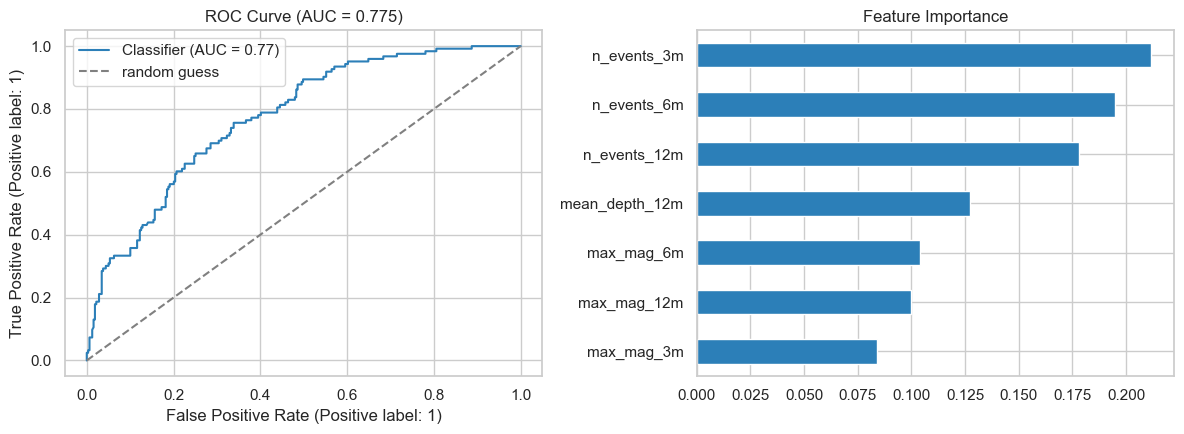

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

RocCurveDisplay.from_predictions(y_test, proba_test, ax=axes[0], color='#2c7fb8')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='random guess')
axes[0].set_title(f"ROC Curve (AUC = {auc:.3f})")
axes[0].legend()

importances = pd.Series(clf.feature_importances_, index=FEATURES).sort_values()
importances.plot(kind='barh', ax=axes[1], color='#2c7fb8')
axes[1].set_title("Feature Importance")
plt.tight_layout()
plt.show()


## Reading the result honestly

An AUC around 0.78 against a ~32% base rate is a **real, meaningful signal** — the
model is clearly picking up on something (unsurprisingly, recent event frequency
dominates feature importance: regions with elevated activity in the last 3-12
months are more likely to see a significant event soon, which lines up with real
seismological concepts like aftershock sequences and swarm activity). It is
*not* a crystal ball: precision at the default threshold sits around 0.45-0.5,
meaning a meaningful share of "high risk" flags won't be followed by a M≥5 event
that month. That's expected for a genuinely near-chaotic physical system — the
fair conclusion is that this is a useful relative-risk signal, good for
prioritizing where to pay closer attention, not a prediction system.



---
<a id="step-5"></a>
# Forecasting Next-Month Regional Magnitude Levels

The previous section asked "is this region's risk elevated right now?" This one asks a more
specific, classic time-series question: **for each region, what will the average
and maximum earthquake magnitude look like next month?**

**A deliberate design choice on the training cutoff.** The dataset already
contains a handful of December 2025 records (through Dec 11 — recall from
earlier that the latest date in the data is December 11, 2025). Training on data
that includes part of the month being forecast would make the forecast partly
hindsight rather than genuinely predictive. So training stops at **November
2025**, and both **December 2025 and January 2026 are treated as fully held-out
future periods** the model never sees. Real data for those two months will be
supplied separately, purely to check the forecast against reality — it is
deliberately kept out of anything the model is fit on.


In [18]:
FORECAST_TRAIN_END = pd.Period("2025-11", freq="M")

fc_source = df_clean.dropna(subset=['event_time'])
fc_source = fc_source[(fc_source['region'] != 'UNKNOWN') & (fc_source['event_time'].dt.to_period('M') <= FORECAST_TRAIN_END)]
fc_source = fc_source[fc_source['event_time'].dt.to_period('M') >= '2015-01']
fc_source = fc_source.assign(year_month=fc_source['event_time'].dt.to_period('M'))

mag_panel = fc_source.groupby(['region', 'year_month']).agg(
    n_events=('magnitude', 'count'),
    mean_mag=('magnitude', 'mean'),
    max_mag=('magnitude', 'max'),
).reset_index()

fc_regions = mag_panel['region'].unique()
fc_months = pd.period_range('2015-01', FORECAST_TRAIN_END, freq='M')
full_idx = pd.MultiIndex.from_product([fc_regions, fc_months], names=['region', 'year_month'])
mag_panel = mag_panel.set_index(['region', 'year_month']).reindex(full_idx).reset_index()
mag_panel = mag_panel.sort_values(['region', 'year_month']).reset_index(drop=True)

print(f"Training window: 2015-01 through {FORECAST_TRAIN_END} ({len(fc_months)} months, {len(fc_regions)} regions)")
print(f"Region-months with zero recorded events: {mag_panel['mean_mag'].isna().mean():.1%}")

Training window: 2015-01 through 2025-11 (131 months, 17 regions)
Region-months with zero recorded events: 10.0%



Months with zero recorded events leave `mean_mag`/`max_mag` undefined for that
region-month — not zero, genuinely missing (no earthquake happened to report a
magnitude for). Linear interpolation across those gaps is a reasonable,
commonly-used way to keep a continuous monthly series for smoothing, so long as
it's stated plainly as an assumption rather than hidden inside the pipeline —
which is what this does.


In [19]:
mag_panel['mean_mag_filled'] = mag_panel.groupby('region')['mean_mag'].transform(
    lambda s: s.interpolate().bfill().ffill()
)
mag_panel['max_mag_filled'] = mag_panel.groupby('region')['max_mag'].transform(
    lambda s: s.interpolate().bfill().ffill()
)
mag_panel[['region', 'year_month', 'mean_mag', 'mean_mag_filled', 'max_mag', 'max_mag_filled']].tail(6)

,region,year_month,mean_mag,mean_mag_filled,max_mag,max_mag_filled
2221,REGION XIII,2025-06,2.254286,2.254286,5.4,5.4
2222,REGION XIII,2025-07,2.284199,2.284199,5.5,5.5
2223,REGION XIII,2025-08,2.225000,2.225000,4.6,4.6
2224,REGION XIII,2025-09,2.288710,2.288710,5.3,5.3
2225,REGION XIII,2025-10,2.229464,2.229464,6.0,6.0
2226,REGION XIII,2025-11,4.633333,4.633333,5.5,5.5



## Method: Holt's linear trend exponential smoothing, from scratch

This environment doesn't have internet access to install a forecasting library
(`statsmodels`, `prophet`, etc.), so the smoothing method is implemented directly
with NumPy — which has a side benefit: nothing here is a black box. **Holt's
method** tracks a smoothed *level* and a smoothed *trend* for a series and
updates both every step:

- `level_t = α · y_t + (1 − α) · (level_{t−1} + trend_{t−1})`
- `trend_t = β · (level_t − level_{t−1}) + (1 − β) · trend_{t−1}`
- forecast `h` steps ahead: `level_t + h · trend_t`

`α` controls how quickly the level reacts to new data; `β` does the same for the
trend. Rather than picking these by hand, both are chosen per region and per
series (mean and max magnitude are fit separately) by a small grid search that
minimizes one-step-ahead error over the region's own history — the same idea
behind hyperparameter tuning in any ML model, just applied to a classical method.

A **naive persistence baseline** (next month = this month's smoothed 12-month
average) is computed alongside every forecast. If Holt's method can't beat that
simple baseline for a given region, that's worth knowing rather than hiding —
magnitude series are noisy enough that a fancier method doesn't automatically win.


In [20]:
def holt_fit_forecast(y, alpha, beta, h):
    '''Holt's linear trend exponential smoothing. Returns in-sample one-step-ahead
    fitted values (for error scoring) and h-step-ahead forecasts.'''
    y = np.asarray(y, dtype=float)
    n = len(y)
    level = y[0]
    trend = y[1] - y[0] if n > 1 else 0.0
    fitted = np.zeros(n)
    fitted[0] = level
    for t in range(1, n):
        fitted[t] = level + trend
        new_level = alpha * y[t] + (1 - alpha) * (level + trend)
        new_trend = beta * (new_level - level) + (1 - beta) * trend
        level, trend = new_level, new_trend
    forecasts = [level + (i + 1) * trend for i in range(h)]
    return fitted, forecasts

def grid_search_holt(y, h=2):
    '''Pick (alpha, beta) minimizing in-sample one-step-ahead MAE.'''
    y = np.asarray(y, dtype=float)
    best = None
    for alpha in np.arange(0.1, 1.0, 0.1):
        for beta in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]:
            fitted, _ = holt_fit_forecast(y, alpha, beta, h)
            mae = np.mean(np.abs(y[1:] - fitted[1:]))
            if best is None or mae < best[0]:
                best = (mae, alpha, beta)
    return best  # (mae, alpha, beta)

def naive_baseline_forecast(y, h=2, window=12):
    '''Persistence baseline: forecast = trailing rolling average.'''
    y = np.asarray(y, dtype=float)
    baseline = y[-window:].mean() if len(y) >= window else y.mean()
    return [baseline] * h

In [21]:
MIN_MONTHS_FOR_SMOOTHING = 24
forecast_rows = []

for region in fc_regions:
    sub = mag_panel[mag_panel['region'] == region].sort_values('year_month')
    n_obs = int(sub['mean_mag'].notna().sum())

    if n_obs < MIN_MONTHS_FOR_SMOOTHING:
        # Too little history to trust a fitted trend -- fall back to the
        # region's overall historical mean, flagged explicitly.
        hist_mean = sub['mean_mag'].mean()
        hist_max = sub['max_mag'].mean()
        forecast_rows.append({
            'region': region, 'n_train_months': n_obs, 'method': 'insufficient history (mean fallback)',
            'mean_mag_dec2025': hist_mean, 'mean_mag_jan2026': hist_mean,
            'max_mag_dec2025': hist_max, 'max_mag_jan2026': hist_max,
            'naive_mean_mag': hist_mean, 'naive_max_mag': hist_max,
        })
        continue

    mae_m, alpha_m, beta_m = grid_search_holt(sub['mean_mag_filled'].values, h=2)
    _, fc_mean = holt_fit_forecast(sub['mean_mag_filled'].values, alpha_m, beta_m, 2)
    naive_mean = naive_baseline_forecast(sub['mean_mag_filled'].values, h=2)

    mae_x, alpha_x, beta_x = grid_search_holt(sub['max_mag_filled'].values, h=2)
    _, fc_max = holt_fit_forecast(sub['max_mag_filled'].values, alpha_x, beta_x, 2)
    naive_max = naive_baseline_forecast(sub['max_mag_filled'].values, h=2)

    forecast_rows.append({
        'region': region, 'n_train_months': n_obs, 'method': f'Holt (α={alpha_m:.1f}/{alpha_x:.1f}, β={beta_m:.1f}/{beta_x:.1f})',
        'mean_mag_dec2025': fc_mean[0], 'mean_mag_jan2026': fc_mean[1],
        'max_mag_dec2025': fc_max[0], 'max_mag_jan2026': fc_max[1],
        'naive_mean_mag': naive_mean[0], 'naive_max_mag': naive_max[0],
    })

forecast_df = pd.DataFrame(forecast_rows).sort_values('region').reset_index(drop=True)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
forecast_df[['region', 'n_train_months', 'mean_mag_dec2025', 'mean_mag_jan2026',
             'max_mag_dec2025', 'max_mag_jan2026', 'naive_mean_mag', 'naive_max_mag']]

,region,n_train_months,mean_mag_dec2025,mean_mag_jan2026,max_mag_dec2025,max_mag_jan2026,naive_mean_mag,naive_max_mag
0,BARMM,121,2.29,2.32,3.27,3.16,2.27,3.88
1,CAR,126,3.21,3.31,4.01,4.03,2.34,4.03
2,NCR,1,1.10,1.10,1.10,1.10,1.10,1.10
3,REGION I,126,3.88,4.01,4.96,4.97,2.63,4.84
4,REGION II,129,3.75,3.85,4.74,4.72,2.79,4.79
5,REGION III,120,4.06,4.06,4.39,4.39,2.39,4.23
6,REGION IV-A,128,3.28,3.38,4.94,4.98,2.25,4.72
7,REGION IV-B,117,2.17,2.16,4.33,4.33,2.14,4.36
8,REGION IX,120,2.19,2.19,3.89,3.89,2.19,4.14
9,REGION V,126,4.50,4.86,4.58,4.57,2.52,4.56


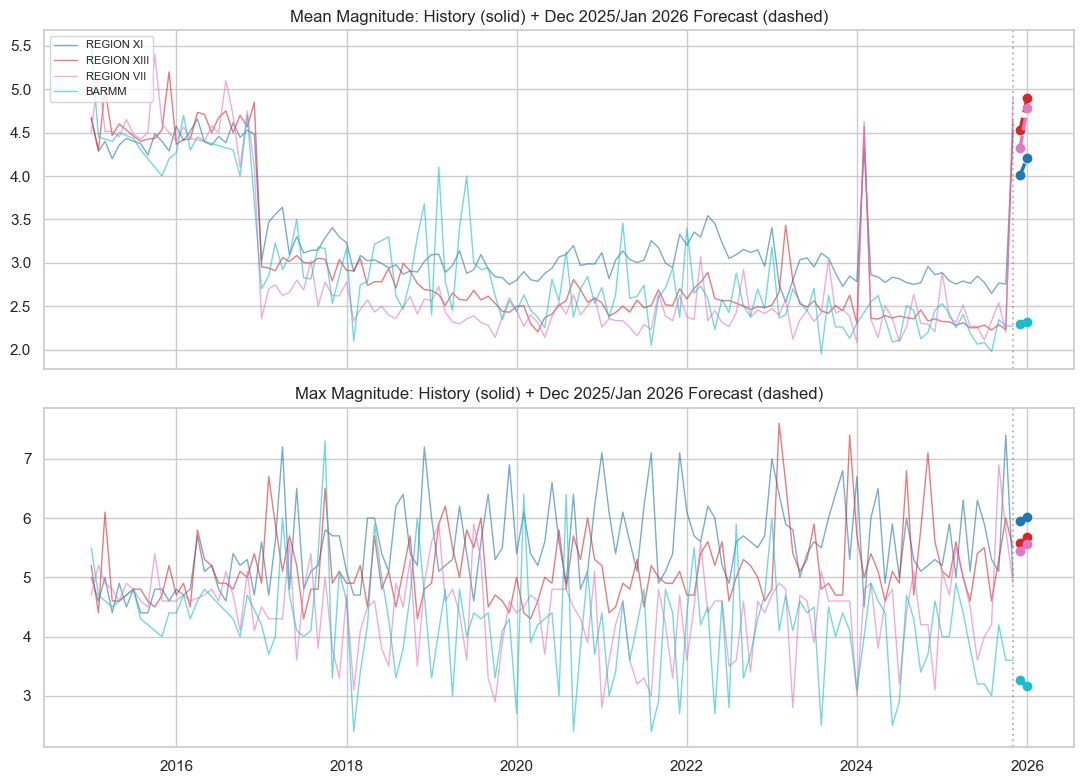

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
plot_regions = ['REGION XI', 'REGION XIII', 'REGION VII', 'BARMM']
colors = plt.cm.tab10(np.linspace(0, 1, len(plot_regions)))

for series_name, ax, title in [('mean_mag_filled', axes[0], 'Mean Magnitude'),
                                 ('max_mag_filled', axes[1], 'Max Magnitude')]:
    for region, color in zip(plot_regions, colors):
        sub = mag_panel[mag_panel['region'] == region].sort_values('year_month')
        x_hist = sub['year_month'].dt.to_timestamp()
        ax.plot(x_hist, sub[series_name], color=color, alpha=0.6, linewidth=1, label=region)

        fc_row = forecast_df[forecast_df['region'] == region].iloc[0]
        col_prefix = 'mean_mag' if 'mean' in series_name else 'max_mag'
        fc_vals = [fc_row[f'{col_prefix}_dec2025'], fc_row[f'{col_prefix}_jan2026']]
        fc_x = pd.PeriodIndex(['2025-12', '2026-01'], freq='M').to_timestamp()
        ax.plot(fc_x, fc_vals, color=color, linewidth=2.5, marker='o', linestyle='--')

    ax.set_title(f"{title}: History (solid) + Dec 2025/Jan 2026 Forecast (dashed)")
    ax.axvline(pd.Period('2025-11', freq='M').to_timestamp(), color='gray', linestyle=':', alpha=0.5)

axes[0].legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


**Reading this honestly:** month-to-month earthquake magnitude is close to a
noisy, near-random-walk process — there's a real but limited amount of
persistence and slow drift for exponential smoothing to pick up on, which is why
the forecast lines mostly track close to each region's recent average rather
than making dramatic swings. That's the correct, humble behavior for this kind
of series; a model that confidently predicted large swings two months out would
be a red flag, not a feature.

The visible drop in average magnitude across nearly every region around
2016–2017 is the same reporting-density change flagged back in the exploratory analysis, not a
real drop in seismicity — before PHIVOLCS's network densified, only the larger
events tended to get caught, which inflates the apparent average; afterward,
the flood of small local M2–3 events pulls the monthly average down. Because
Holt's method weights recent months far more heavily than distant ones, that
older regime has little direct influence on the Dec 2025/Jan 2026 forecast, but
it's worth naming rather than leaving as an unexplained cliff in the chart.

## Comparing against real data

Real PHIVOLCS bulletin data was supplied for this evaluation, covering
**December 15, 2025 through January 31, 2026** — deliberately never used in
training (the forecasting section's training cutoff was November 2025, set
before this data existed). One thing worth flagging honestly before looking
at any numbers: **December is still a partial month** (Dec 15–31 only,
missing Dec 1–14), so it's compared against the December forecast with that
caveat attached. **January, however, is a complete calendar month** (Jan
1–31), so the January comparison is a genuine apples-to-apples test of the
full-month forecast — the more trustworthy of the two.

The bulletin data also doesn't come with a region column directly — PHIVOLCS
reports a municipality/province in the location text instead (e.g. "012 km S
84° W of Tabogon (**Cebu**)"). Mapping province → administrative region uses
the same standard Philippine regional breakdown the original dataset's region
labels already follow (verified directly against it below).


In [24]:
PROVINCE_TO_REGION = {
    'ILOCOS NORTE':'REGION I','ILOCOS SUR':'REGION I','LA UNION':'REGION I','PANGASINAN':'REGION I',
    'BATANES':'REGION II','CAGAYAN':'REGION II','ISABELA':'REGION II','NUEVA VIZCAYA':'REGION II','QUIRINO':'REGION II',
    'AURORA':'REGION III','BATAAN':'REGION III','BULACAN':'REGION III','NUEVA ECIJA':'REGION III','PAMPANGA':'REGION III','TARLAC':'REGION III','ZAMBALES':'REGION III',
    'BATANGAS':'REGION IV-A','CAVITE':'REGION IV-A','LAGUNA':'REGION IV-A','QUEZON':'REGION IV-A','RIZAL':'REGION IV-A',
    'MARINDUQUE':'REGION IV-B','OCCIDENTAL MINDORO':'REGION IV-B','ORIENTAL MINDORO':'REGION IV-B','PALAWAN':'REGION IV-B','ROMBLON':'REGION IV-B',
    'ALBAY':'REGION V','CAMARINES NORTE':'REGION V','CAMARINES SUR':'REGION V','CATANDUANES':'REGION V','MASBATE':'REGION V','SORSOGON':'REGION V',
    'AKLAN':'REGION VI','ANTIQUE':'REGION VI','CAPIZ':'REGION VI','GUIMARAS':'REGION VI','ILOILO':'REGION VI','NEGROS OCCIDENTAL':'REGION VI',
    'BOHOL':'REGION VII','CEBU':'REGION VII','NEGROS ORIENTAL':'REGION VII','SIQUIJOR':'REGION VII',
    'BILIRAN':'REGION VIII','EASTERN SAMAR':'REGION VIII','LEYTE':'REGION VIII','NORTHERN SAMAR':'REGION VIII','SAMAR':'REGION VIII','SOUTHERN LEYTE':'REGION VIII',
    'ZAMBOANGA DEL NORTE':'REGION IX','ZAMBOANGA DEL SUR':'REGION IX','ZAMBOANGA SIBUGAY':'REGION IX',
    'BUKIDNON':'REGION X','CAMIGUIN':'REGION X','LANAO DEL NORTE':'REGION X','MISAMIS OCCIDENTAL':'REGION X','MISAMIS ORIENTAL':'REGION X',
    'DAVAO DE ORO':'REGION XI','DAVAO DEL NORTE':'REGION XI','DAVAO DEL SUR':'REGION XI','DAVAO OCCIDENTAL':'REGION XI','DAVAO ORIENTAL':'REGION XI',
    'COTABATO':'REGION XII','SARANGANI':'REGION XII','SOUTH COTABATO':'REGION XII','SULTAN KUDARAT':'REGION XII',
    'AGUSAN DEL NORTE':'REGION XIII','AGUSAN DEL SUR':'REGION XIII','DINAGAT ISLANDS':'REGION XIII','SURIGAO DEL NORTE':'REGION XIII','SURIGAO DEL SUR':'REGION XIII',
    'ABRA':'CAR','APAYAO':'CAR','BENGUET':'CAR','IFUGAO':'CAR','KALINGA':'CAR','MOUNTAIN PROVINCE':'CAR',
    'BASILAN':'BARMM','LANAO DEL SUR':'BARMM','MAGUINDANAO DEL NORTE':'BARMM','MAGUINDANAO DEL SUR':'BARMM','SULU':'BARMM','TAWI-TAWI':'BARMM',
}
# A handful of bulletin rows give a municipality with no parenthetical province.
MUNICIPALITY_OVERRIDES = {'LICUAN': 'ABRA'}

actuals_raw = pd.read_csv("/Users/ohmaegod/csv/thefuture.csv")
actuals_raw.columns = ['datetime_str', 'latitude', 'longitude', 'depth', 'magnitude', 'location']
actuals_raw['event_time'] = pd.to_datetime(actuals_raw['datetime_str'], format='%d %B %Y - %I:%M %p')

province = actuals_raw['location'].str.extract(r'\(([^)]+)\)\s*$')[0].str.upper()
missing = province.isna()
province.loc[missing] = actuals_raw.loc[missing, 'location'].str.extract(r'of\s+(\S+)')[0].str.upper().map(MUNICIPALITY_OVERRIDES)
actuals_raw['region'] = province.map(PROVINCE_TO_REGION).fillna('UNKNOWN')

print(f"Loaded {len(actuals_raw)} real PHIVOLCS bulletin events, "
      f"{actuals_raw['event_time'].min()} to {actuals_raw['event_time'].max()}")
print(f"Unmapped region rows: {(actuals_raw['region'] == 'UNKNOWN').sum()}")

Loaded 2986 real PHIVOLCS bulletin events, 2025-12-15 00:01:00 to 2026-01-31 23:43:00
Unmapped region rows: 1


In [25]:

dec_window = actuals_raw[(actuals_raw['event_time'] >= '2025-12-15') & (actuals_raw['event_time'] < '2026-01-01')]
jan_window = actuals_raw[(actuals_raw['event_time'] >= '2026-01-01') & (actuals_raw['event_time'] < '2026-02-01')]

print(f"December window: {dec_window['event_time'].min()} -> {dec_window['event_time'].max()}  (partial month, {len(dec_window)} events)")
print(f"January window:  {jan_window['event_time'].min()} -> {jan_window['event_time'].max()}  (complete month, {len(jan_window)} events)")

dec_actual = dec_window.groupby('region').agg(mean_mag=('magnitude', 'mean'), max_mag=('magnitude', 'max'))
jan_actual = jan_window.groupby('region').agg(mean_mag=('magnitude', 'mean'), max_mag=('magnitude', 'max'))

comparison = forecast_df.set_index('region').copy()
comparison['mean_mag_dec2025_actual'] = dec_actual['mean_mag']
comparison['mean_mag_jan2026_actual'] = jan_actual['mean_mag']
comparison['max_mag_dec2025_actual'] = dec_actual['max_mag']
comparison['max_mag_jan2026_actual'] = jan_actual['max_mag']

# Combined score across both months
comparison['holt_mean_mag_mae'] = (
    (comparison['mean_mag_dec2025'] - comparison['mean_mag_dec2025_actual']).abs()
    + (comparison['mean_mag_jan2026'] - comparison['mean_mag_jan2026_actual']).abs()
) / 2
comparison['naive_mean_mag_mae'] = (
    (comparison['naive_mean_mag'] - comparison['mean_mag_dec2025_actual']).abs()
    + (comparison['naive_mean_mag'] - comparison['mean_mag_jan2026_actual']).abs()
) / 2
comparison['holt_max_mag_mae'] = (
    (comparison['max_mag_dec2025'] - comparison['max_mag_dec2025_actual']).abs()
    + (comparison['max_mag_jan2026'] - comparison['max_mag_jan2026_actual']).abs()
) / 2
comparison['naive_max_mag_mae'] = (
    (comparison['naive_max_mag'] - comparison['max_mag_dec2025_actual']).abs()
    + (comparison['naive_max_mag'] - comparison['max_mag_jan2026_actual']).abs()
) / 2

n_scored = comparison['mean_mag_dec2025_actual'].notna().sum()
print(f"Regions with actual data in both windows: {n_scored} of {len(comparison)}")
print(f"\nCombined (Dec partial + Jan complete) MAE:")
print(f"  Mean-magnitude  —  Holt: {comparison['holt_mean_mag_mae'].mean():.3f}   "
      f"Naive baseline: {comparison['naive_mean_mag_mae'].mean():.3f}")
print(f"  Max-magnitude   —  Holt: {comparison['holt_max_mag_mae'].mean():.3f}   "
      f"Naive baseline: {comparison['naive_max_mag_mae'].mean():.3f}")

# January-only breakdown -- the trustworthy, full-calendar-month comparison
jan_holt_mean_mae = (comparison['mean_mag_jan2026'] - comparison['mean_mag_jan2026_actual']).abs()
jan_naive_mean_mae = (comparison['naive_mean_mag'] - comparison['mean_mag_jan2026_actual']).abs()
jan_holt_max_mae = (comparison['max_mag_jan2026'] - comparison['max_mag_jan2026_actual']).abs()
jan_naive_max_mae = (comparison['naive_max_mag'] - comparison['max_mag_jan2026_actual']).abs()
print(f"\nJanuary ONLY (complete calendar month -- the trustworthy comparison):")
print(f"  Mean-magnitude  —  Holt: {jan_holt_mean_mae.mean():.3f}   Naive baseline: {jan_naive_mean_mae.mean():.3f}")
print(f"  Max-magnitude   —  Holt: {jan_holt_max_mae.mean():.3f}   Naive baseline: {jan_naive_max_mae.mean():.3f}")

comparison[['n_train_months', 'mean_mag_dec2025', 'mean_mag_dec2025_actual',
            'mean_mag_jan2026', 'mean_mag_jan2026_actual',
            'max_mag_dec2025', 'max_mag_dec2025_actual',
            'max_mag_jan2026', 'max_mag_jan2026_actual']].round(2)


December window: 2025-12-15 00:01:00 -> 2025-12-31 23:49:00  (partial month, 762 events)
January window:  2026-01-01 00:56:00 -> 2026-01-31 23:43:00  (complete month, 2224 events)
Regions with actual data in both windows: 16 of 17

Combined (Dec partial + Jan complete) MAE:
  Mean-magnitude  —  Holt: 1.489   Naive baseline: 0.296
  Max-magnitude   —  Holt: 0.951   Naive baseline: 0.882

January ONLY (complete calendar month -- the trustworthy comparison):
  Mean-magnitude  —  Holt: 1.592   Naive baseline: 0.303
  Max-magnitude   —  Holt: 0.949   Naive baseline: 0.804


,n_train_months,mean_mag_dec2025,mean_mag_dec2025_actual,mean_mag_jan2026,mean_mag_jan2026_actual,max_mag_dec2025,max_mag_dec2025_actual,max_mag_jan2026,max_mag_jan2026_actual
region,,,,,,,,,
BARMM,121,2.29,2.08,2.32,1.95,3.27,2.50,3.16,3.70
CAR,126,3.21,1.92,3.31,2.05,4.01,2.60,4.03,3.60
NCR,1,1.10,NaN,1.10,NaN,1.10,NaN,1.10,NaN
REGION I,126,3.88,2.28,4.01,2.31,4.96,3.40,4.97,4.40
REGION II,129,3.75,3.18,3.85,2.59,4.74,6.60,4.72,3.90
REGION III,120,4.06,2.13,4.06,2.04,4.39,4.70,4.39,3.40
REGION IV-A,128,3.28,1.90,3.38,1.85,4.94,3.90,4.98,3.10
REGION IV-B,117,2.17,1.93,2.16,1.92,4.33,3.20,4.33,3.50
REGION IX,120,2.19,2.12,2.19,2.22,3.89,3.40,3.89,4.40


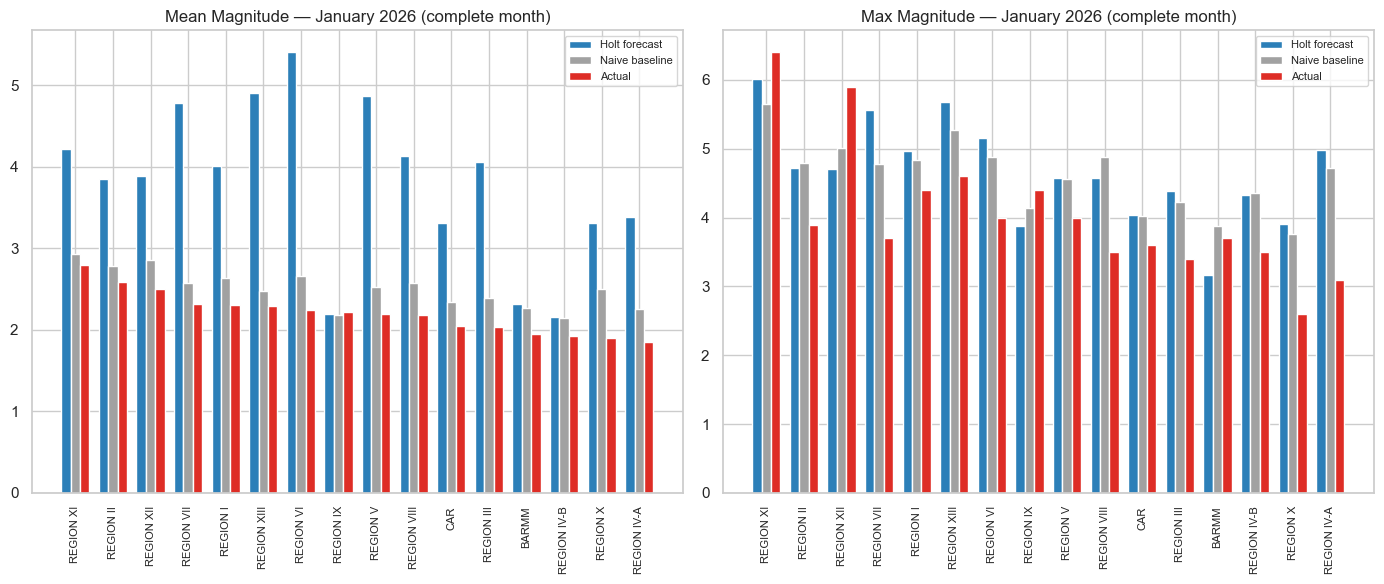

In [26]:
plot_df = comparison.dropna(subset=['mean_mag_jan2026_actual']).sort_values('mean_mag_jan2026_actual', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
x = np.arange(len(plot_df))
width = 0.25

for ax, forecast_col, actual_col, naive_col, title in [
    (axes[0], 'mean_mag_jan2026', 'mean_mag_jan2026_actual', 'naive_mean_mag', 'Mean Magnitude — January 2026 (complete month)'),
    (axes[1], 'max_mag_jan2026', 'max_mag_jan2026_actual', 'naive_max_mag', 'Max Magnitude — January 2026 (complete month)'),
]:
    ax.bar(x - width, plot_df[forecast_col], width, label='Holt forecast', color='#2c7fb8')
    ax.bar(x, plot_df[naive_col], width, label='Naive baseline', color='#a1a1a1')
    ax.bar(x + width, plot_df[actual_col], width, label='Actual', color='#de2d26')
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df.index, rotation=90, fontsize=8)
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


**Reading the scored result honestly:** the naive baseline won clearly, and
the complete-month January comparison actually makes the case *stronger* than
the partial-December one. Isolating January alone — the one genuine
apples-to-apples, full-calendar-month test — Holt's method posted a
mean-magnitude MAE of **1.59** against the naive baseline's **0.30**, more than
five times worse, and even lost narrowly on max magnitude (**0.95** vs
**0.80**). Looking at *why* is more useful than just reporting the numbers:
across most regions, Holt's mean-magnitude forecast came in noticeably higher
(often 3.5–5.0) than what actually happened (mostly 1.9–2.8). Training data
through November 2025 included a period of somewhat elevated activity in
several regions, and Holt's trend term extrapolated that elevation forward —
but January reverted toward each region's typical background level instead.
The rolling 12-month average, having no trend term to overshoot with, absorbed
that same elevated period as part of a longer average and landed much closer
to reality.

This is exactly the scenario the naive baseline was included to catch: a
fitted trend model can look more sophisticated while actually doing worse than
"assume next month looks like the recent average" on a series that
mean-reverts more than it trends. With a full calendar month now available to
check against, this isn't a fluke of a short evaluation window — the fair
conclusion is that **the naive baseline is the better choice for this problem**,
at least at this resolution and training window, and that's a legitimate,
useful finding on its own. Knowing that a fancier method doesn't earn its
complexity is worth knowing, and the honest next step (noted below) would be
to either shorten Holt's effective memory (a higher smoothing weight on
recent months) or drop the trend term entirely and see whether a pure
level-smoothing model closes the gap.



**Known limitations, stated plainly:** two months is a short forecast horizon to
validate a trend-based method on — a single unusual event (a large aftershock
sequence, say) can swing a region's actual monthly mean or max magnitude well
outside anything recent history would suggest, and that's a property of the
underlying physical process, not a flaw specific to this method. Regions with
under 24 months of usable history fall back to a simple historical average
rather than a fitted trend, since fitting Holt's method on very short series
tends to overreact to noise. The naive persistence baseline is included
specifically so that if Holt's method doesn't actually add value over "next
month looks like the recent average," that's visible rather than hidden.



---
<a id="summary"></a>
# Summary

## The throughline

Every section here hinges on the same habit: before trusting a number, ask what
could make it misleading, and check. That habit is what actually produced each
result below — the choices weren't arbitrary, they were responses to something
the data revealed once it was looked at closely.

## Results and Discussion

**Cleaning surfaced a real structural difference between the two sources, not
just noise.** The reason to check date/time formats at all was that PHIVOLCS
and USGS are independent networks with independent export pipelines — there
was no reason to assume they'd agree on formatting. That check paid off: USGS
uses 12-hour am/pm time with an inconsistent day-first/month-first date order
(~9,700 rows genuinely ambiguous), while PHIVOLCS is internally consistent.
Checking for duplicate events (matching on time *and* space, not just time —
the reason to add the spatial check was that two networks could easily log
unrelated events minutes apart) found under 1% overlap, which answered a real
question: these catalogs turned out to be complementary, not redundant.
PHIVOLCS's local network catches the small events USGS's global network isn't
dense enough for.

**Exploring the trend before modeling it prevented a wrong conclusion later.**
The obvious read of the yearly event count is "seismicity is increasing" — the
chart genuinely looks that way. The reason to cross-check that against
reporting history (rather than take the chart at face value) was that a
sudden level shift in *count* data is a classic symptom of a change in how the
data was collected, not necessarily a change in the underlying phenomenon.
That check found the answer: PHIVOLCS's network density increased around
2017, which explains the shift without any change in real seismicity. That
same 2017 boundary then directly justified restricting the later forecasting
model to 2015+ data — a decision made *because* of what this step found, not
before it.

**Clustering needed a spherical distance metric because the alternative would
have silently distorted the result.** Latitude/longitude aren't a flat grid;
using Euclidean distance on them would bias cluster shapes even over the
Philippines' relatively narrow span. Choosing haversine distance and tuning
`eps`/`min_samples` via a small grid search (rather than picking numbers that
"looked right") produced 45 spatial clusters that — when checked against
known geology — track the Mindanao trench system and the eastern Philippine
Trench almost exactly. That correspondence is the actual validation: the
method wasn't just plotting points, it recovered structure that matches
independently known fault geography.

**The risk score works because it was scoped to what's actually learnable.**
Framing the target as "will this region see a M≥5 event next month" instead of
"predict the next earthquake" was a deliberate choice to ask a question
seismology can actually answer. The result — AUC ≈ 0.78 against a 32% base
rate, with recent event frequency as the dominant signal — reflects a real,
modest, defensible pattern (elevated recent activity correlates with near-term
risk, consistent with aftershock/swarm behavior) rather than an inflated claim.
The time-based train/test split was what made that number trustworthy in the
first place — a random split would have let the model see the future through
neighboring months and reported a better number that wouldn't have meant
anything.

**The magnitude forecast produced a negative result, and that result is only
credible because of how it was tested.** Training was cut off at November
2025 specifically so December and January would be genuinely unseen — this
was the one methodological choice made in anticipation of a comparison that
didn't exist yet at the time. When real PHIVOLCS data for a complete January
became available, Holt's fitted-trend method lost badly to a naive rolling
average (mean-magnitude MAE 1.59 vs 0.30). That outcome traces directly back
to a specific mechanism: training data included a period of elevated activity
in several regions, Holt's trend term extrapolated that elevation forward, and
January reverted toward baseline instead. The naive baseline, having no trend
term to overshoot with, absorbed that same period as part of a longer average
and landed closer to reality. Including that baseline in the first place is
what made this failure visible instead of hidden behind a single, unquestioned
forecast.

## Known limitations, stated plainly

1. Date-order is genuinely ambiguous for about 9,700 USGS rows (data cleaning) — resolved
   with a documented default assumption, not silently.
2. Deduplication uses a distance/time heuristic, not authoritative event IDs —
   good enough to demonstrate the idea, not a substitute for real record linkage.
3. Clustering was run on a subsample for speed; final parameters should be re-run
   on the full dataset before drawing firm conclusions from it.
4. The risk model is validated only on the 2015+ period, when reporting is dense
   and consistent — it hasn't been tested against earlier or very different data.
5. The magnitude forecast's one evaluation window, while now a complete month,
   is still a single window — enough to show Holt's method underperforming here,
   not enough to rule out it ever working with different tuning.